# Tissue clustering heatmaps for GTEx, PaxDb, and TCGA expression/abundance data

R notebook translation of Sections 7-8 of `filtering_source_exploration.ipynb`:

7. Within-source hierarchical clustering of tissues (Spearman correlation)
8. Top 50 most variable genes/proteins, hierarchically clustered

Extended with a **TCGA** section (per-cohort median expression, computed
from the raw per-sample STAR-TPM matrices cached by `download_TCGA.py`),
mirroring the GTEx/PaxDb top-variable-gene heatmaps.

In [1]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(readr)
  library(tibble)
  library(data.table)
  library(matrixStats)
  library(pheatmap)
  library(RColorBrewer)
  library(grid)
  library(ggplot2)
  library(patchwork)
})

In [2]:
REPO_ROOT     <- normalizePath(".")
EXPR_FILE     <- file.path(REPO_ROOT, "data", "expression_by_tissue.gct")
PAXDB_FILE    <- file.path(REPO_ROOT, "data", "paxdb_all_tissues.tsv")
UBERON_GROUPS_FILE <- file.path(REPO_ROOT, "data", "tissue_uberon_groups.tsv")
TCGA_RAW_DIR  <- file.path(REPO_ROOT, "data", "tcga_raw")

OUT_ROOT      <- file.path(REPO_ROOT, "sanity_check_outputs")
GTEX_OUT      <- file.path(OUT_ROOT, "gtex")
PAXDB_OUT     <- file.path(OUT_ROOT, "paxdb")
TCGA_OUT      <- file.path(OUT_ROOT, "tcga")
dir.create(OUT_ROOT, showWarnings = FALSE)
dir.create(GTEX_OUT, showWarnings = FALSE)
dir.create(PAXDB_OUT, showWarnings = FALSE)
dir.create(TCGA_OUT, showWarnings = FALSE)

In [3]:
# -- Shared color scales (declared once, reused by every heatmap below) ------

VALUE_PALETTE <- colorRampPalette(brewer.pal(9, "YlGnBu"))          # raw/log10 value heatmaps
CORR_PALETTE  <- colorRampPalette(c("#3B4CC0", "white", "#B40426")) # correlation heatmaps
SOURCE_COLORS <- c(PaxDb = "#FF7F0E", GTEx = "#1F77B4")             # GTEx vs. PaxDb annotation

## Data loading — GTEx and PaxDb

In [4]:
# GTEx GCT: header on line 3, genes x tissues, median TPM. Duplicate gene
# symbols are collapsed with the row-wise median (matches the Python notebook).
read_gtex_median_tpm <- function(path) {
  raw <- read_tsv(path, skip = 2, show_col_types = FALSE) %>%
    rename(ensembl = Name, symbol = Description)
  tissue_cols <- setdiff(colnames(raw), c("ensembl", "symbol"))

  raw %>%
    group_by(symbol) %>%
    summarise(across(all_of(tissue_cols), \(x) median(x, na.rm = TRUE)), .groups = "drop") %>%
    column_to_rownames("symbol") %>%
    as.matrix()
}

# PaxDb wide TSV: id + one column per tissue, ppm. Missing entries mean
# "not detected" (~0 abundance), not "unknown", so fill rather than drop.
read_paxdb <- function(path) {
  mat <- read_tsv(path, show_col_types = FALSE) %>%
    column_to_rownames("id") %>%
    as.matrix()
  mat[is.na(mat)] <- 0
  mat
}

gtex_mat  <- read_gtex_median_tpm(EXPR_FILE)
paxdb_mat <- read_paxdb(PAXDB_FILE)

gtex_log  <- log2(gtex_mat + 1)
paxdb_log <- log2(paxdb_mat + 1)

ERROR: [1m[33mError[39m:[22m
[1m[22m[33m![39m [34m/nfs/home/students/m.tan/BA/data/expression_by_tissue.gct[39m does not exist.


## Data loading — TCGA

`download_TCGA.py` caches one raw STAR-TPM matrix per cohort in
`data/tcga_raw/` (genes x samples, GDC hub convention: values are
**log2(TPM + 1)**, not linear TPM). There is no pre-aggregated
median-per-cohort matrix the way `median_tpm_by_tissue.gct` exists for
GTEx, so it is built here: each cohort file is collapsed to a single
median-expression column, giving a genes x cohorts matrix analogous to
`gtex_mat`.

The median is taken directly on the log2(TPM + 1) values rather than in
linear TPM space, since the median commutes with any monotonic transform
(`median(log2(x + 1)) == log2(median(x) + 1)`) — this avoids exponentiating
every one of the ~60,000 x (samples) values per cohort just to re-log them
afterwards. Rows are also keyed by bare Ensembl gene ID (version and
`_PAR_Y` suffixes stripped); the handful of genes this collapses onto the
same ID (pseudoautosomal-region duplicates) are combined the same way
`read_gtex_median_tpm()` combines duplicate gene symbols, via row-wise
median.

Reading all 33 cohorts (the largest, BRCA, is ~340 MB gzipped) takes a
while — per the login banner, run this via `sbatch` rather than directly
on the login node.

In [5]:
read_tcga_cohort_median_log <- function(path) {
  dt  <- fread(cmd = paste("zcat", shQuote(path)), header = TRUE)
  ids <- sub("\\..*$", "", dt[[1]])                 # drop Ensembl version / _PAR_Y suffix
  mat <- as.matrix(dt[, -1, with = FALSE])
  med <- rowMedians(mat, na.rm = TRUE)
  tapply(med, ids, median)                          # collapse PAR_Y duplicates onto base ID
}

tcga_files   <- list.files(TCGA_RAW_DIR, pattern = "^TCGA-.*\\.star_tpm\\.tsv\\.gz$", full.names = TRUE)
tcga_cohorts <- sub("^TCGA-(.*)\\.star_tpm\\.tsv\\.gz$", "\\1", basename(tcga_files))

tcga_cohort_medians <- vector("list", length(tcga_files))
names(tcga_cohort_medians) <- tcga_cohorts
for (i in seq_along(tcga_files)) {
  message(sprintf("[%d/%d] TCGA-%s", i, length(tcga_files), tcga_cohorts[i]))
  tcga_cohort_medians[[i]] <- read_tcga_cohort_median_log(tcga_files[i])
}

tcga_common_genes <- Reduce(intersect, lapply(tcga_cohort_medians, names))
tcga_log <- do.call(cbind, lapply(tcga_cohort_medians, `[`, tcga_common_genes))
rownames(tcga_log) <- tcga_common_genes
colnames(tcga_log) <- tcga_cohorts

tcga_mat <- 2^tcga_log - 1   # raw median TPM, for parity with gtex_mat / paxdb_mat

[1/33] TCGA-ACC

[2/33] TCGA-BLCA

[3/33] TCGA-BRCA

[4/33] TCGA-CESC

[5/33] TCGA-CHOL

[6/33] TCGA-COAD

[7/33] TCGA-DLBC

[8/33] TCGA-ESCA

[9/33] TCGA-GBM

[10/33] TCGA-HNSC

[11/33] TCGA-KICH

[12/33] TCGA-KIRC

[13/33] TCGA-KIRP

[14/33] TCGA-LAML

[15/33] TCGA-LGG

[16/33] TCGA-LIHC

[17/33] TCGA-LUAD

[18/33] TCGA-LUSC

[19/33] TCGA-MESO

[20/33] TCGA-OV

[21/33] TCGA-PAAD

[22/33] TCGA-PCPG

[23/33] TCGA-PRAD

[24/33] TCGA-READ

[25/33] TCGA-SARC

[26/33] TCGA-SKCM

[27/33] TCGA-STAD

[28/33] TCGA-TGCT

[29/33] TCGA-THCA

[30/33] TCGA-THYM

[31/33] TCGA-UCEC

[32/33] TCGA-UCS

[33/33] TCGA-UVM



## Tissue grouping — GTEx and PaxDb (UBERON)

In [ ]:
# Tissue -> group assignments come from group_tissues_uberon.py, which climbs
# each tissue's UBERON is_a/part_of ancestry to the nearest organ-level term
# (e.g. every GTEx "Brain - ..." subregion and PaxDb's BRAIN/CEREBRAL_CORTEX/
# FRONTAL_CORTEX all collapse to a single "brain" group), then climbs once
# more to the nearest organ-system-level term (e.g. "brain" and "spinal cord"
# both collapse to "nervous system"). Both tiers are shown as separate
# annotation strips below. Run that script to regenerate
# data/tissue_uberon_groups.tsv after the underlying tissue lists change.

uberon_groups <- read_tsv(UBERON_GROUPS_FILE, show_col_types = FALSE)

build_lookup <- function(source_name, level_col) {
  rows <- filter(uberon_groups, source == source_name)
  setNames(rows[[level_col]], rows$tissue)
}

TISSUE_GROUP_LOOKUPS <- list(
  GTEx  = list(organ = build_lookup("GTEx", "organ_group"), system = build_lookup("GTEx", "organ_system")),
  PaxDB = list(organ = build_lookup("PaxDB", "organ_group"), system = build_lookup("PaxDB", "organ_system"))
)

# Tissues absent from the UBERON grouping (e.g. PaxDb body fluids like
# AMNIOTIC_FLUID that aren't organs) fall back to their own name as a
# singleton group, so they still get a distinct label/color instead of NA.
tissue_group_name <- function(tissue_names, source = c("GTEx", "PaxDB"), level = c("organ", "system")) {
  source <- match.arg(source)
  level <- match.arg(level)
  lookup <- TISSUE_GROUP_LOOKUPS[[source]][[level]]
  group <- unname(lookup[tissue_names])
  ifelse(is.na(group), tissue_names, group)
}

In [ ]:
# Two fixed group -> color mappings (one per level), each built once from the
# union of GTEx and PaxDb groups at that level, so the same group (e.g.
# "brain", "nervous system") always gets the same color across every heatmap
# instead of a per-call, per-source assignment. The two levels use distinct
# palette families so their annotation strips/legends stay visually separable.
all_organ_groups  <- sort(unique(c(
  tissue_group_name(colnames(gtex_mat), "GTEx", "organ"),
  tissue_group_name(colnames(paxdb_mat), "PaxDB", "organ")
)))
all_system_groups <- sort(unique(c(
  tissue_group_name(colnames(gtex_mat), "GTEx", "system"),
  tissue_group_name(colnames(paxdb_mat), "PaxDB", "system")
)))
organ_group_colors <- setNames(
  colorRampPalette(c(brewer.pal(12, "Paired"), brewer.pal(12, "Set3")))(length(all_organ_groups)),
  all_organ_groups
)
SYSTEM_PALETTE <- c(
 "#E58606","#5D69B1","#52BCA3","#99C945","#CC61B0","#24796C","#DAA51B", "#2F8AC4" ,"#764E9F","#ED645A","#CC3A8E","#A5AA99"
)
# Some PaxDb sample types (biofluids, whole organism) have no UBERON organ
# mapping and fall back to their own name as a singleton "system" group (see
# tissue_group_name() above). There are always exactly 12 real organ systems,
# matching SYSTEM_PALETTE 1:1, so those get the fixed palette directly rather
# than through colorRampPalette() interpolation, which - once fallback groups
# are mixed in - can generate two interpolated colors close enough to be
# visually indistinguishable (e.g. cardiovascular vs. renal system). Fallback
# groups get their own grey ramp so they never compete with organ-system hues.
canonical_systems  <- sort(unique(uberon_groups$organ_system))
fallback_groups    <- setdiff(all_system_groups, canonical_systems)
system_group_colors <- c(
  setNames(SYSTEM_PALETTE[seq_along(canonical_systems)], canonical_systems),
  setNames(colorRampPalette(c("grey35", "grey75"))(length(fallback_groups)), fallback_groups)
)

In [ ]:
# Single-column annotation data frame keyed by tissue name ("Organ system" =
# system-level), for pheatmap's annotation_row/annotation_col. Heatmaps only
# show the organ-system tier; the organ-level tier is still used by the PCA
# plots in the last section via tissue_group_name() directly.
tissue_annotation_df <- function(tissue_names, source) {
  data.frame(
    "Organ system" = tissue_group_name(tissue_names, source, "system"),
    row.names = tissue_names,
    check.names = FALSE
  )
}

# Subset of the global system-level color map restricted to the groups
# actually present among tissue_names. pheatmap draws a legend entry for
# every color it is handed, so passing the full palette to a GTEx-only (or
# PaxDb-only) heatmap would list groups that never appear in it.
tissue_annotation_colors <- function(tissue_names, source) {
  list(
    "Organ system" = system_group_colors[sort(unique(tissue_group_name(tissue_names, source, "system")))]
  )
}

## Tissue-of-origin, cancer-type, and organ-system grouping — TCGA

TCGA cohorts are tumor types, not raw tissue samples, so
`group_tissues_uberon.py` (and `data/tissue_uberon_groups.tsv`) has no entry
for them. Rather than guess UBERON terms, cohort labels are mapped to three
fixed, public lookups instead — mirroring the two-tier (organ /
organ-system) annotation used for GTEx and PaxDb above, plus a third tier
specific to tumor data:

- **Tissue of origin** (organ-level, as before).
- **Cancer type** (histological classification: adenocarcinoma, squamous
  cell carcinoma, melanoma, glioma, sarcoma, ...), from the standard TCGA
  study-abbreviation table
  (https://gdc.cancer.gov/resources-tcga-users/tcga-code-tables/tcga-study-abbreviations).
  A few cohorts span more than one histology in reality (e.g. ESCA mixes
  adenocarcinoma and squamous cell carcinoma, CESC mixes squamous cell
  carcinoma and adenocarcinoma) and are bucketed under the broader
  "Carcinoma" label rather than picked arbitrarily.
- **Organ system** (coarse anatomical grouping of "Tissue of origin", e.g.
  Kidney + Bladder -> "Urinary System"), analogous to the GTEx/PaxDb
  "Organ system" tier.

All three are kept as their own annotation/color system rather than folded
into `organ_group_colors` / `system_group_colors` above, since there's no
guarantee the two naming schemes agree on strings (e.g. "brain" vs.
"Brain") or bucket boundaries (e.g. whether breast counts as reproductive
or integumentary) — a mismatch there would silently produce two different
colors for what should be the same group rather than an error.

In [33]:
TCGA_COHORT_TISSUE <- c(
  ACC = "Adrenal Gland", BLCA = "Bladder", BRCA = "Breast", CESC = "Cervix",
  CHOL = "Bile Duct", COAD = "Colon", DLBC = "Lymph Nodes", ESCA = "Esophagus",
  GBM = "Brain", HNSC = "Head and Neck", KICH = "Kidney", KIRC = "Kidney",
  KIRP = "Kidney", LAML = "Bone Marrow", LGG = "Brain", LIHC = "Liver",
  LUAD = "Lung", LUSC = "Lung", MESO = "Pleura", OV = "Ovary", PAAD = "Pancreas",
  PCPG = "Adrenal Gland", PRAD = "Prostate", READ = "Rectum", SARC = "Soft Tissue",
  SKCM = "Skin", STAD = "Stomach", TGCT = "Testis", THCA = "Thyroid",
  THYM = "Thymus", UCEC = "Uterus", UCS = "Uterus", UVM = "Eye"
)

# Histological classification, not organ of origin (e.g. both LUAD and PAAD
# are "Adenocarcinoma" despite being lung vs. pancreas). Cohorts with mixed
# histology in reality (ESCA, CESC) are bucketed under "Carcinoma" rather
# than assigned one subtype arbitrarily.
TCGA_COHORT_CANCER_TYPE <- c(
  ACC = "Carcinoma", BLCA = "Carcinoma", BRCA = "Adenocarcinoma", CESC = "Carcinoma",
  CHOL = "Adenocarcinoma", COAD = "Adenocarcinoma", DLBC = "Lymphoma", ESCA = "Carcinoma",
  GBM = "Glioma", HNSC = "Squamous Cell Carcinoma", KICH = "Carcinoma", KIRC = "Adenocarcinoma",
  KIRP = "Adenocarcinoma", LAML = "Leukemia", LGG = "Glioma", LIHC = "Carcinoma",
  LUAD = "Adenocarcinoma", LUSC = "Squamous Cell Carcinoma", MESO = "Mesothelioma",
  OV = "Adenocarcinoma", PAAD = "Adenocarcinoma", PCPG = "Neuroendocrine Tumor",
  PRAD = "Adenocarcinoma", READ = "Adenocarcinoma", SARC = "Sarcoma", SKCM = "Melanoma",
  STAD = "Adenocarcinoma", TGCT = "Germ Cell Tumor", THCA = "Carcinoma", THYM = "Thymoma",
  UCEC = "Adenocarcinoma", UCS = "Carcinosarcoma", UVM = "Melanoma"
)

# Coarse organ-of-origin -> organ-system grouping, analogous to the
# organ_group -> organ_system climb group_tissues_uberon.py does for
# GTEx/PaxDb. A few assignments are judgment calls on genuinely
# multi-system organs (e.g. thymus is lymphatic *and* endocrine; head and
# neck cancers mostly arise from upper-aerodigestive mucosa, hence
# "Digestive" over "Respiratory").
TCGA_ORGAN_SYSTEM <- c(
  "Adrenal Gland" = "Endocrine System", "Thyroid" = "Endocrine System",
  "Bile Duct" = "Digestive System", "Colon" = "Digestive System",
  "Esophagus" = "Digestive System", "Head and Neck" = "Digestive System",
  "Liver" = "Digestive System", "Pancreas" = "Digestive System",
  "Rectum" = "Digestive System", "Stomach" = "Digestive System",
  "Bladder" = "Urinary System", "Kidney" = "Urinary System",
  "Bone Marrow" = "Hematologic/Lymphatic System", "Lymph Nodes" = "Hematologic/Lymphatic System",
  "Thymus" = "Hematologic/Lymphatic System",
  "Brain" = "Nervous System", "Eye" = "Nervous System",
  "Breast" = "Reproductive System", "Cervix" = "Reproductive System",
  "Ovary" = "Reproductive System", "Prostate" = "Reproductive System",
  "Testis" = "Reproductive System", "Uterus" = "Reproductive System",
  "Lung" = "Respiratory System", "Pleura" = "Respiratory System",
  "Skin" = "Integumentary System",
  "Soft Tissue" = "Musculoskeletal System"
)
TCGA_COHORT_SYSTEM <- setNames(unname(TCGA_ORGAN_SYSTEM[TCGA_COHORT_TISSUE]), names(TCGA_COHORT_TISSUE))

# Shared qualitative palette builder for the three TCGA annotation tiers
# above (tissue, cancer type, organ system) - same Paired+Set3 interpolation
# organ_group_colors uses, just applied three times instead of once.
tcga_discrete_colors <- function(values) {
  setNames(
    colorRampPalette(c(brewer.pal(12, "Paired"), brewer.pal(12, "Set3")))(length(unique(values))),
    sort(unique(values))
  )
}

tcga_tissue_colors     <- tcga_discrete_colors(TCGA_COHORT_TISSUE)
tcga_cancertype_colors <- tcga_discrete_colors(TCGA_COHORT_CANCER_TYPE)
tcga_system_colors     <- tcga_discrete_colors(TCGA_COHORT_SYSTEM)

tcga_annotation_df <- function(cohorts) {
  data.frame(
#    "Tissue of origin" = unname(TCGA_COHORT_TISSUE[cohorts]),
    "Cancer type" = unname(TCGA_COHORT_CANCER_TYPE[cohorts]),
    "Organ system" = unname(TCGA_COHORT_SYSTEM[cohorts]),
    row.names = cohorts,
    check.names = FALSE
  )
}

tcga_annotation_colors <- function(cohorts) {
  list(
    "Tissue of origin" = tcga_tissue_colors[sort(unique(TCGA_COHORT_TISSUE[cohorts]))],
    "Cancer type" = tcga_cancertype_colors[sort(unique(TCGA_COHORT_CANCER_TYPE[cohorts]))],
    "Organ system" = tcga_system_colors[sort(unique(TCGA_COHORT_SYSTEM[cohorts]))]
  )
}

## Plotting helper

In [13]:
# Draw a pheatmap result to a PNG with "Tissue" / row-count axis titles added
# (pheatmap has no built-in xlab/ylab), matching the axis labels used in the
# Python exploration notebook / playground.ipynb heatmaps.
save_heatmap_with_axis_labels <- function(pheatmap_result, out_path, width, height,
                                           xlab = NULL, ylab = NULL) {
  png(out_path, width = width, height = height, units = "in", res = 200)
  grid.newpage()
  grid.draw(pheatmap_result$gtable)
  if (!is.null(xlab)) {
    grid.text(xlab, x = 0.5, y = 0.01, gp = gpar(fontsize = 12))
  }
  if (!is.null(ylab)) {
    grid.text(ylab, x = 0.01, y = 0.5, rot = 90, gp = gpar(fontsize = 12))
  }
  dev.off()
}

## Section 8: top 50 most variable genes/proteins, hierarchically clustered

In [14]:
top_variable_heatmap <- function(mat, title, out_file, ann_col, ann_colors, value_label,
                                  out_dir = OUT_ROOT, exclude_mito = TRUE, mito_pattern = "^MT-",
                                  n_top = 50, log_norm = TRUE) {
  data <- mat
  data[is.na(data)] <- 0
  if (exclude_mito) {
    data <- data[!grepl(mito_pattern, rownames(data)), , drop = FALSE]
  }

  row_var <- apply(data, 1, var)
  top <- data[order(row_var, decreasing = TRUE)[seq_len(min(n_top, nrow(data)))], , drop = FALSE]

  if (log_norm) {
    max_val <- max(top)
    breaks <- unique(c(0, 10^seq(0, ceiling(log10(max_val)))))
    breaks[length(breaks)] <- max_val
    colors <- VALUE_PALETTE(length(breaks) - 1)
    legend_breaks <- breaks
    legend_labels <- formatC(breaks, format = "fg", big.mark = ",")
  } else {
    breaks <- seq(min(top), max(top), length.out = 101)
    colors <- VALUE_PALETTE(100)
    legend_breaks <- pretty(breaks)
    legend_labels <- legend_breaks
  }

  result <- pheatmap(
    top,
    color = colors,
    breaks = breaks,
    legend_breaks = legend_breaks,
    legend_labels = legend_labels,
    clustering_distance_rows = "euclidean",
    clustering_distance_cols = "euclidean",
    clustering_method = "average",
    annotation_col = ann_col,
    annotation_colors = ann_colors,
    annotation_legend = TRUE,
    annotation_names_col = FALSE,
    show_rownames = TRUE,
    show_colnames = TRUE,
    fontsize_row = 6,
    fontsize_col = 6,
    angle_col = 45,
    treeheight_row = 80,
    treeheight_col = 120,
    main = title,
    silent = TRUE
  )

  row_label <- if (exclude_mito) {
    sprintf("Top %d non-mitochondrial genes/proteins by variance", n_top)
  } else {
    sprintf("Top %d genes/proteins by variance", n_top)
  }

  save_heatmap_with_axis_labels(
    result, file.path(out_dir, out_file), width = 24, height = 14,
    xlab = "Tissue", ylab = row_label
  )
  result
}

In [ ]:
top_variable_heatmap(
  gtex_mat,
  "GTEx - top 50 most variable genes across tissues (raw median TPM)",
  "gtex_top50_variable_clustermap_R.png",
  ann_col = tissue_annotation_df(colnames(gtex_mat), "GTEx"),
  ann_colors = tissue_annotation_colors(colnames(gtex_mat), "GTEx"),
  value_label = "TPM",
  out_dir = GTEX_OUT
)

top_variable_heatmap(
  paxdb_mat,
  "PaxDb - top 50 most variable proteins across tissues (raw ppm)",
  "paxdb_top50_variable_clustermap_R.png",
  ann_col = tissue_annotation_df(colnames(paxdb_mat), "PaxDB"),
  ann_colors = tissue_annotation_colors(colnames(paxdb_mat), "PaxDB"),
  value_label = "ppm",
  out_dir = PAXDB_OUT
)

In [ ]:
# Same two heatmaps, but on log2(x + 1)-transformed values: top-50 variance
# genes/proteins are reselected on the log2 matrix (not the raw top-50 list),
# and plotted on a linear color scale since the values are already log2.
top_variable_heatmap(
  gtex_log,
  "GTEx - top 50 most variable genes across tissues (log2 TPM + 1)",
  "gtex_top50_variable_clustermap_log_R.png",
  ann_col = tissue_annotation_df(colnames(gtex_log), "GTEx"),
  ann_colors = tissue_annotation_colors(colnames(gtex_log), "GTEx"),
  value_label = "log2(TPM + 1)",
  log_norm = FALSE,
  out_dir = GTEX_OUT
)

top_variable_heatmap(
  paxdb_log,
  "PaxDb - top 50 most variable proteins across tissues (log2 ppm + 1)",
  "paxdb_top50_variable_clustermap_log_R.png",
  ann_col = tissue_annotation_df(colnames(paxdb_log), "PaxDB"),
  ann_colors = tissue_annotation_colors(colnames(paxdb_log), "PaxDB"),
  value_label = "log2(ppm + 1)",
  log_norm = FALSE,
  out_dir = PAXDB_OUT
)

In [ ]:
# Combined GTEx + PaxDb: join on shared genes (all tissues, prefixed by
# source), log2-transform, then reselect the top-50 variable rows within the
# joined log2 matrix (not a union of the two individual top-50 lists).
gtex_prefixed  <- gtex_mat
paxdb_prefixed <- paxdb_mat
colnames(gtex_prefixed)  <- paste0("GTEx_", colnames(gtex_prefixed))
colnames(paxdb_prefixed) <- paste0("PaxDb_", colnames(paxdb_prefixed))

shared_genes  <- intersect(rownames(paxdb_prefixed), rownames(gtex_prefixed))
combined_mat  <- cbind(paxdb_prefixed[shared_genes, ], gtex_prefixed[shared_genes, ])
combined_log  <- log2(combined_mat + 1)

source_of <- ifelse(startsWith(colnames(combined_log), "PaxDb_"), "PaxDb", "GTEx")
source_ann_col <- data.frame(
  Source = source_of, row.names = colnames(combined_log), check.names = FALSE
)

top_variable_heatmap(
  combined_log,
  "GTEx + PaxDb combined - top 50 most variable genes/proteins (log2 value + 1)",
  "combined_top50_variable_clustermap_R.png",
  ann_col = source_ann_col,
  ann_colors = list(Source = SOURCE_COLORS),
  value_label = "log2(value + 1)",
  log_norm = FALSE
)

## TCGA: top 50 most variable genes, hierarchically clustered

Same analysis as above, applied to the per-cohort median-TPM matrix built
in the TCGA data-loading section, with columns annotated by tissue of
origin instead of GTEx/PaxDb tissue.

`exclude_mito`'s default `mito_pattern = "^MT-"` matches gene *symbols*
(`MT-ND1`, ...) and never matches TCGA's Ensembl-ID rownames, so without
an override it would silently stop excluding mitochondrial genes here —
they are extremely highly expressed and highly variable across cohorts,
and would otherwise dominate the top-50 list. `TCGA_MT_ENSEMBL_IDS` is
the fixed set of GRCh38 Ensembl IDs for the 13 mitochondrial
protein-coding genes, passed in as an explicit `mito_pattern` instead.

Combining TCGA into the GTEx+PaxDb heatmap above isn't done here since
that join is keyed by gene symbol and TCGA rows are still Ensembl IDs —
see the ID-space mapping TODO in `CLAUDE.md`.

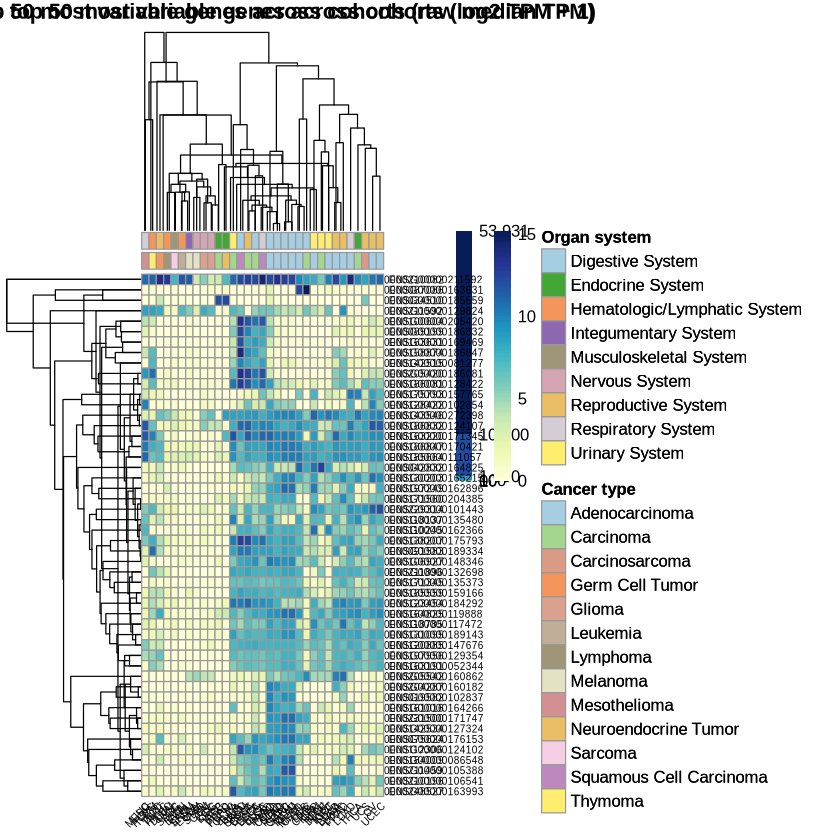

In [34]:
# GRCh38 Ensembl IDs of the 13 mitochondrial protein-coding genes.
TCGA_MT_ENSEMBL_IDS <- c(
  "ENSG00000198888", "ENSG00000198763", "ENSG00000198804", "ENSG00000198712",
  "ENSG00000228253", "ENSG00000198899", "ENSG00000198938", "ENSG00000198840",
  "ENSG00000212907", "ENSG00000198886", "ENSG00000198786", "ENSG00000198695",
  "ENSG00000198727"
)
tcga_mito_pattern <- paste0("^(", paste(TCGA_MT_ENSEMBL_IDS, collapse = "|"), ")$")

top_variable_heatmap(
  tcga_mat,
  "TCGA - top 50 most variable genes across cohorts (raw median TPM)",
  "tcga_top50_variable_clustermap_R.png",
  ann_col = tcga_annotation_df(colnames(tcga_mat)),
  ann_colors = tcga_annotation_colors(colnames(tcga_mat)),
  value_label = "TPM",
  mito_pattern = tcga_mito_pattern,
  out_dir = TCGA_OUT
)

top_variable_heatmap(
  tcga_log,
  "TCGA - top 50 most variable genes across cohorts (log2 TPM + 1)",
  "tcga_top50_variable_clustermap_log_R.png",
  ann_col = tcga_annotation_df(colnames(tcga_log)),
  ann_colors = tcga_annotation_colors(colnames(tcga_log)),
  value_label = "log2(TPM + 1)",
  log_norm = FALSE,
  mito_pattern = tcga_mito_pattern,
  out_dir = TCGA_OUT
)

## Section 9: PCA of tissue profiles, colored by tissue group / organ system

R equivalent of Section 6 of `filtering_source_exploration.ipynb` (PCA of
each source's log-transformed tissue profiles), but colored with the same
two-tier UBERON tissue taxonomy used for the heatmap annotation strips
above (`tissue_group_name()` / `organ_group_colors` / `system_group_colors`)
instead of that notebook's ad-hoc leading-token grouping, so tissue
groupings are consistent across every plot in this notebook. For each
source, both colorings of the same PCA are placed side by side via
patchwork.

In [ ]:
# One row per tissue (observations), one column per gene/protein (features);
# matches the log2 matrices already built above (gtex_log, paxdb_log).
pca_scores_for_source <- function(log_mat, source_name) {
  mat <- log_mat
  mat[is.na(mat)] <- 0
  data <- t(mat)
  keep <- apply(data, 2, function(col) sd(col) > 0)
  data <- data[, keep, drop = FALSE]

  pca <- prcomp(data, center = TRUE, scale. = FALSE)
  var_explained <- (pca$sdev^2 / sum(pca$sdev^2))[1:2]

  scores <- as.data.frame(pca$x[, 1:2])
  colnames(scores) <- c("PC1", "PC2")
  scores$tissue <- rownames(scores)
  scores[["Tissue group"]] <- tissue_group_name(scores$tissue, source_name, "organ")
  scores[["Organ system"]] <- tissue_group_name(scores$tissue, source_name, "system")
  attr(scores, "var_explained") <- var_explained
  scores
}

plot_pca_panel <- function(scores, color_col, color_map, subtitle) {
  var_explained <- attr(scores, "var_explained")
  ggplot(scores, aes(x = PC1, y = PC2, color = .data[[color_col]])) +
    geom_hline(yintercept = 0, color = "grey85", linewidth = 0.4) +
    geom_vline(xintercept = 0, color = "grey85", linewidth = 0.4) +
    geom_point(size = 2.8, alpha = 0.9) +
    scale_color_manual(values = color_map, name = color_col) +
    labs(
      x = sprintf("PC1 (%.1f%% variance)", var_explained[1] * 100),
      y = sprintf("PC2 (%.1f%% variance)", var_explained[2] * 100),
      subtitle = subtitle
    ) +
    theme_minimal(base_size = 12) +
    theme(
      panel.grid.minor = element_blank(),
      legend.key.size = unit(0.35, "cm"),
      legend.text = element_text(size = 7),
      legend.title = element_text(size = 8, face = "bold")
    ) +
    guides(color = guide_legend(ncol = 1, override.aes = list(size = 2.6)))
}

plot_source_pca_pair <- function(log_mat, source_name, title, out_file, out_dir) {
  scores <- pca_scores_for_source(log_mat, source_name)

  present_organ  <- sort(unique(scores[["Tissue group"]]))
  present_system <- sort(unique(scores[["Organ system"]]))

  p_organ  <- plot_pca_panel(scores, "Tissue group", organ_group_colors[present_organ], "Colored by tissue group")
  p_system <- plot_pca_panel(scores, "Organ system", system_group_colors[present_system], "Colored by organ system")

  combined <- (p_organ | p_system) +
    plot_annotation(title = title, theme = theme(plot.title = element_text(size = 16, face = "bold")))

  ggsave(file.path(out_dir, out_file), combined, width = 16, height = 6.5, dpi = 200)
  combined
}

In [ ]:
plot_source_pca_pair(
  gtex_log, "GTEx",
  "PCA of GTEx median TPM by tissue",
  "gtex_pca_tissue_groups_R.png",
  out_dir = GTEX_OUT
)

In [ ]:
plot_source_pca_pair(
  paxdb_log, "PaxDB",
  "PCA of PaxDb ppm by tissue",
  "paxdb_pca_tissue_groups_R.png",
  out_dir = PAXDB_OUT
)